# Part B

In [1]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

set_seed(42)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


In [3]:
BASE_PATH = "/Users/shreyash/Documents/Sem3DL/AT2DL"
DATA_PATH = os.path.join(BASE_PATH, "food-101")

train_dir = os.path.join(DATA_PATH, "train")
test_dir = os.path.join(DATA_PATH, "test")

print("Train path exists:", os.path.exists(train_dir))
print("Test path exists:", os.path.exists(test_dir))

Train path exists: False
Test path exists: False


In [4]:
class Food101Dataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        self.root_dir = root_dir
        self.transform = transform

        meta_path = os.path.join(root_dir, "meta")
        file_path = os.path.join(meta_path, f"{split}.txt")

        with open(file_path, "r") as f:
            self.image_paths = [line.strip() for line in f.readlines()]

        with open(os.path.join(meta_path, "classes.txt"), "r") as f:
            self.classes = [line.strip() for line in f.readlines()]

        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_rel_path = self.image_paths[idx]
        label_name = img_rel_path.split('/')[0]

        img_path = os.path.join(self.root_dir, "images", img_rel_path + ".jpg")
        image = Image.open(img_path).convert("RGB")

        label = self.class_to_idx[label_name]

        if self.transform:
            image = self.transform(image)

        return image, label

In [5]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

In [6]:
print("Top-level folders:")
print(os.listdir(DATA_PATH))

Top-level folders:
['.DS_Store', 'images', 'meta', 'license_agreement.txt', 'README.txt']


In [7]:
train_dir = os.path.join(DATA_PATH, "train")
test_dir = os.path.join(DATA_PATH, "test")

train_dataset = Food101Dataset(DATA_PATH, split="train", transform=train_transform)
test_dataset = Food101Dataset(DATA_PATH, split="test", transform=test_transform)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Number of training samples:", len(train_dataset))
print("Number of test samples:", len(test_dataset))
print("Number of classes:", len(train_dataset.classes))

Number of training samples: 75750
Number of test samples: 25250
Number of classes: 101


In [8]:
images, labels = next(iter(train_loader))
print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])


In [9]:
def build_mobilenet_v3_model(num_classes=101):
    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
    
    for param in model.parameters():
        param.requires_grad = False
    
    in_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )
    
    return model

In [10]:
def print_trainable_layers(model):
    print("Trainable parameters:")
    for name, param in model.named_parameters():
        if param.requires_grad:
            print(name)

In [11]:
def apply_finetune_strategy_1(model):
    """
    Strategy 1:
    Unfreeze only the last few feature blocks and the classifier.
    Earlier backbone layers remain frozen.
    """
    for param in model.parameters():
        param.requires_grad = False

    # classifier must always be trainable
    for param in model.classifier.parameters():
        param.requires_grad = True

    # Unfreeze final backbone blocks
    # MobileNetV3 small usually has features indexed from 0 to 12
    for idx in [11, 12]:
        for param in model.features[idx].parameters():
            param.requires_grad = True

    return model

In [12]:
def apply_finetune_strategy_2(model):
    """
    Strategy 2:
    Unfreeze the deeper half of the backbone and the classifier.
    Earlier layers remain frozen.
    """
    for param in model.parameters():
        param.requires_grad = False

    for param in model.classifier.parameters():
        param.requires_grad = True

    total_feature_blocks = len(model.features)
    start_idx = total_feature_blocks // 2   # unfreeze last 50%

    for idx in range(start_idx, total_feature_blocks):
        for param in model.features[idx].parameters():
            param.requires_grad = True

    return model

In [13]:
mobilenet_ft_1 = build_mobilenet_v3_model(num_classes=101)
mobilenet_ft_1 = apply_finetune_strategy_1(mobilenet_ft_1).to(device)

print("Strategy 1 trainable layers:")
print_trainable_layers(mobilenet_ft_1)

Strategy 1 trainable layers:
Trainable parameters:
features.11.block.0.0.weight
features.11.block.0.1.weight
features.11.block.0.1.bias
features.11.block.1.0.weight
features.11.block.1.1.weight
features.11.block.1.1.bias
features.11.block.2.fc1.weight
features.11.block.2.fc1.bias
features.11.block.2.fc2.weight
features.11.block.2.fc2.bias
features.11.block.3.0.weight
features.11.block.3.1.weight
features.11.block.3.1.bias
features.12.0.weight
features.12.1.weight
features.12.1.bias
classifier.0.weight
classifier.0.bias
classifier.3.weight
classifier.3.bias
classifier.6.weight
classifier.6.bias


In [14]:
mobilenet_ft_2 = build_mobilenet_v3_model(num_classes=101)
mobilenet_ft_2 = apply_finetune_strategy_2(mobilenet_ft_2).to(device)

print("Strategy 2 trainable layers:")
print_trainable_layers(mobilenet_ft_2)

Strategy 2 trainable layers:
Trainable parameters:
features.6.block.0.0.weight
features.6.block.0.1.weight
features.6.block.0.1.bias
features.6.block.1.0.weight
features.6.block.1.1.weight
features.6.block.1.1.bias
features.6.block.2.fc1.weight
features.6.block.2.fc1.bias
features.6.block.2.fc2.weight
features.6.block.2.fc2.bias
features.6.block.3.0.weight
features.6.block.3.1.weight
features.6.block.3.1.bias
features.7.block.0.0.weight
features.7.block.0.1.weight
features.7.block.0.1.bias
features.7.block.1.0.weight
features.7.block.1.1.weight
features.7.block.1.1.bias
features.7.block.2.fc1.weight
features.7.block.2.fc1.bias
features.7.block.2.fc2.weight
features.7.block.2.fc2.bias
features.7.block.3.0.weight
features.7.block.3.1.weight
features.7.block.3.1.bias
features.8.block.0.0.weight
features.8.block.0.1.weight
features.8.block.0.1.bias
features.8.block.1.0.weight
features.8.block.1.1.weight
features.8.block.1.1.bias
features.8.block.2.fc1.weight
features.8.block.2.fc1.bias
fea

In [15]:
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    model.to(device)

    for epoch in range(epochs):
        start_time = time.time()

        # Training
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            if isinstance(outputs, tuple):
                outputs = outputs[0]

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / total
        train_acc = 100 * correct / total

        # Validation
        model.eval()
        val_running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                if isinstance(outputs, tuple):
                    outputs = outputs[0]

                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_loss = val_running_loss / total
        val_acc = 100 * correct / total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        end_time = time.time()

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
            f"Time: {end_time - start_time:.2f}s"
        )

    return model, history

In [16]:
mobilenet_ft_1, history_ft_1 = train_model(
    mobilenet_ft_1,
    train_loader,
    test_loader,
    epochs=10,
    lr=1e-4
)

Epoch [1/10] | Train Loss: 3.5069 | Train Acc: 18.11% | Val Loss: 2.3856 | Val Acc: 40.40% | Time: 380.21s
Epoch [2/10] | Train Loss: 2.6790 | Train Acc: 33.27% | Val Loss: 2.0162 | Val Acc: 48.14% | Time: 362.36s
Epoch [3/10] | Train Loss: 2.4225 | Train Acc: 39.09% | Val Loss: 1.8281 | Val Acc: 52.20% | Time: 363.32s
Epoch [4/10] | Train Loss: 2.2601 | Train Acc: 42.53% | Val Loss: 1.7265 | Val Acc: 54.78% | Time: 363.55s
Epoch [5/10] | Train Loss: 2.1411 | Train Acc: 45.19% | Val Loss: 1.6463 | Val Acc: 56.27% | Time: 362.81s
Epoch [6/10] | Train Loss: 2.0450 | Train Acc: 47.68% | Val Loss: 1.5675 | Val Acc: 58.29% | Time: 363.93s
Epoch [7/10] | Train Loss: 1.9714 | Train Acc: 49.31% | Val Loss: 1.5303 | Val Acc: 59.15% | Time: 363.46s
Epoch [8/10] | Train Loss: 1.9035 | Train Acc: 50.95% | Val Loss: 1.4862 | Val Acc: 60.21% | Time: 363.33s
Epoch [9/10] | Train Loss: 1.8504 | Train Acc: 52.28% | Val Loss: 1.4396 | Val Acc: 61.39% | Time: 359.55s
Epoch [10/10] | Train Loss: 1.7991 | 

In [17]:
mobilenet_ft_2, history_ft_2 = train_model(
    mobilenet_ft_2,
    train_loader,
    test_loader,
    epochs=10,
    lr=1e-4
)

Epoch [1/10] | Train Loss: 3.1932 | Train Acc: 23.64% | Val Loss: 1.9424 | Val Acc: 50.25% | Time: 418.45s
Epoch [2/10] | Train Loss: 2.2503 | Train Acc: 42.63% | Val Loss: 1.5518 | Val Acc: 59.12% | Time: 415.78s
Epoch [3/10] | Train Loss: 1.9432 | Train Acc: 49.67% | Val Loss: 1.3926 | Val Acc: 62.75% | Time: 416.93s
Epoch [4/10] | Train Loss: 1.7610 | Train Acc: 54.16% | Val Loss: 1.3100 | Val Acc: 64.65% | Time: 415.68s
Epoch [5/10] | Train Loss: 1.6319 | Train Acc: 57.39% | Val Loss: 1.2136 | Val Acc: 66.89% | Time: 414.88s
Epoch [6/10] | Train Loss: 1.5244 | Train Acc: 59.89% | Val Loss: 1.1815 | Val Acc: 67.60% | Time: 416.65s
Epoch [7/10] | Train Loss: 1.4497 | Train Acc: 61.66% | Val Loss: 1.1412 | Val Acc: 68.74% | Time: 415.63s
Epoch [8/10] | Train Loss: 1.3725 | Train Acc: 63.52% | Val Loss: 1.1217 | Val Acc: 69.42% | Time: 414.42s
Epoch [9/10] | Train Loss: 1.3076 | Train Acc: 65.00% | Val Loss: 1.1001 | Val Acc: 69.89% | Time: 415.28s
Epoch [10/10] | Train Loss: 1.2522 | 

In [18]:
def compute_accuracy(model, data_loader):
    model.eval()
    
    num_correct = 0
    num_samples = 0

    with torch.no_grad():
        for batch_images, batch_labels in data_loader:
            batch_images = batch_images.to(device)
            batch_labels = batch_labels.to(device)

            predictions = model(batch_images)
            if isinstance(predictions, tuple):
                predictions = predictions[0]

            predicted_classes = predictions.argmax(dim=1)

            num_samples += batch_labels.size(0)
            num_correct += (predicted_classes == batch_labels).sum().item()

    accuracy = (num_correct / num_samples) * 100
    return accuracy

In [19]:
results_partB = {}

ft1_acc = compute_accuracy(mobilenet_ft_1, test_loader)
ft2_acc = compute_accuracy(mobilenet_ft_2, test_loader)

results_partB["Fine-Tuned Model 1"] = ft1_acc
results_partB["Fine-Tuned Model 2"] = ft2_acc

print("Fine-Tuned Model 1 Accuracy: {:.2f}%".format(ft1_acc))
print("Fine-Tuned Model 2 Accuracy: {:.2f}%".format(ft2_acc))

Fine-Tuned Model 1 Accuracy: 61.38%
Fine-Tuned Model 2 Accuracy: 70.62%


In [20]:
# From Part A notebook
partA_mobilenet_acc = 51.16

comparison_results = {
    "Part A MobileNetV3": partA_mobilenet_acc,
    "Fine-Tuned Model 1": ft1_acc,
    "Fine-Tuned Model 2": ft2_acc
}

comparison_df = pd.DataFrame({
    "Model": list(comparison_results.keys()),
    "Test Accuracy (%)": list(comparison_results.values())
})

comparison_df

,Model,Test Accuracy (%)
0,Part A MobileNetV3,51.160000
1,Fine-Tuned Model 1,61.382178
2,Fine-Tuned Model 2,70.617822


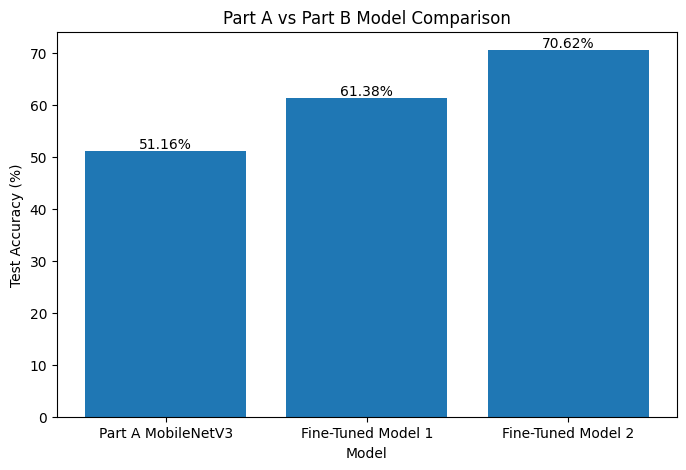

In [24]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Model"], comparison_df["Test Accuracy (%)"])
plt.title("Part A vs Part B Model Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.xticks()

for i, value in enumerate(comparison_df["Test Accuracy (%)"]):
    plt.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.show()

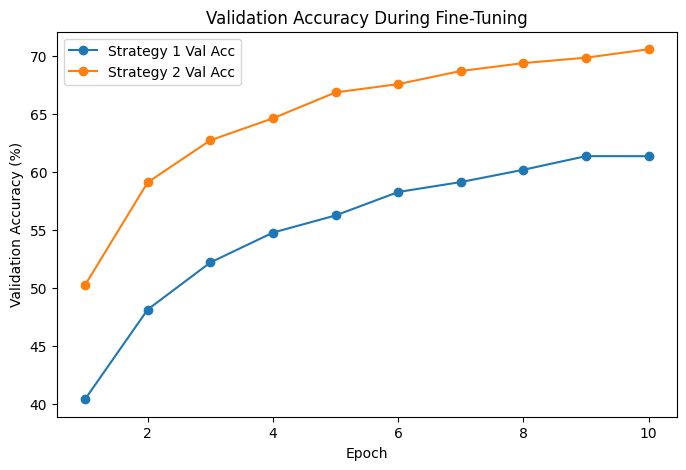

In [25]:
epochs_range = range(1, 11)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history_ft_1["val_acc"], marker="o", label="Strategy 1 Val Acc")
plt.plot(epochs_range, history_ft_2["val_acc"], marker="o", label="Strategy 2 Val Acc")
plt.title("Validation Accuracy During Fine-Tuning")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.legend()
plt.show()

In [26]:
best_model_name = max(comparison_results, key=comparison_results.get)
best_model_acc = comparison_results[best_model_name]

print(f"Best final model: {best_model_name}")
print(f"Best test accuracy: {best_model_acc:.2f}%")

Best final model: Fine-Tuned Model 2
Best test accuracy: 70.62%
